In [55]:
from google.colab import drive
drive.mount('/content/drive')

base_path = "/content/drive/MyDrive/AI-NN files/"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc

import tensorflow as tf
from tensorflow.keras import layers, Model

In [57]:
cols = ['length_of_study_time_step']  # + important features if needed

df = pd.read_csv(
    base_path + "processed_data.csv",
    usecols=cols,
    nrows=200000
)

In [58]:

# --- CREATE ANOMALY TARGET (FIXED) ---

# example: high values = anomaly
threshold = df['length_of_study_time_step'].quantile(0.95)

df['anomaly'] = (df['length_of_study_time_step'] > threshold).astype(int)

target_col = 'anomaly'

X = df.drop(columns=[target_col])
X_numeric = X.select_dtypes(include=[np.number])
y = df[target_col]

print("Anomaly distribution:")
print(y.value_counts())

Anomaly distribution:
anomaly
0    190072
1      9928
Name: count, dtype: int64


Scaling

In [59]:


# drop target first
X = df.drop(columns=[target_col])

# keep only numeric
X_numeric = X.select_dtypes(include=[np.number])

#  remove NaNs
X_numeric = X_numeric.replace([np.inf, -np.inf], np.nan)
X_numeric = X_numeric.fillna(X_numeric.median())

print("After cleaning:", X_numeric.isna().sum().sum(), "NaNs remaining")

# scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numeric)

y = df[target_col].values

After cleaning: 0 NaNs remaining


In [60]:
print("Max value:", np.max(X_scaled))
print("Min value:", np.min(X_scaled))

Max value: 1.5924705380094453
Min value: -2.8551462977801942


Sequence creation

In [61]:
# --- MEMORY-SAFE SEQUENCE CREATION ---

sample_size = 50000  # safe

X_small = X_scaled[:sample_size]
y_small = y[:sample_size]

print("Using subset:", X_small.shape)

Using subset: (50000, 1)


In [62]:
# --- MEMORY-SAFE SEQUENCE CREATION ---

def create_sequences(X_data, y_data, window, step=5):
    X_seq, y_seq = [], []

    for i in range(0, len(X_data) - window, step):  # 🔥 step reduces size
        X_seq.append(X_data[i:i+window])
        y_seq.append(y_data[i+window])

    return np.array(X_seq), np.array(y_seq)

window_size = 24

X_seq, y_seq = create_sequences(X_small, y_small, window_size)

print("X_seq:", X_seq.shape)

X_seq: (9996, 24, 1)


Train/val/test

In [63]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X_seq, y_seq,
    test_size=0.30,
    shuffle=True,        # ✅ FIX
    stratify=y_seq       # ✅ CRITICAL
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    shuffle=True,
    stratify=y_temp
)

print("Train:", np.bincount(y_train))
print("Val:", np.bincount(y_val))
print("Test:", np.bincount(y_test))

Train: [5608 1389]
Val: [1201  298]
Test: [1202  298]


Pair creation

In [64]:
def create_pairs(X, y, max_pairs=20000):
    pairs = []
    labels = []

    normal_idx = np.where(y == 0)[0]
    anomaly_idx = np.where(y == 1)[0]

    min_len = min(len(normal_idx), len(anomaly_idx), max_pairs)

    if min_len == 0:
        print("No pairs possible. Check class balance.")
        return np.array([]), np.array([])

    for i in range(min_len - 1):
        # similar
        pairs.append([X[normal_idx[i]], X[normal_idx[i+1]]])
        labels.append(1)

        # different
        pairs.append([X[normal_idx[i]], X[anomaly_idx[i]]])
        labels.append(0)

    return np.array(pairs), np.array(labels)


pairs_train, y_pairs_train = create_pairs(X_train, y_train)
pairs_val, y_pairs_val = create_pairs(X_val, y_val)

print("Train pairs:", pairs_train.shape)
print("Val pairs:", pairs_val.shape)

Train pairs: (2776, 2, 24, 1)
Val pairs: (594, 2, 24, 1)


Shared CNN (feature extractor)

In [65]:
def build_shared_network(input_shape):
    inp = layers.Input(shape=input_shape)

    x = layers.Conv1D(64, 3, activation='relu', padding='same')(inp)
    x = layers.MaxPooling1D(2)(x)

    x = layers.Conv1D(128, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling1D(2)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)  # REQUIRED SIZE = 128

    return Model(inp, x)

input_shape = X_train.shape[1:]
shared_net = build_shared_network(input_shape)

Euclidean distance

In [66]:
def euclidean_distance(vects):
    x, y = vects
    sum_square = tf.reduce_sum(tf.square(x - y), axis=1, keepdims=True)


    return tf.sqrt(tf.maximum(sum_square, 1e-7))

Siamese model

In [67]:
input_a = layers.Input(shape=input_shape)
input_b = layers.Input(shape=input_shape)

feat_a = shared_net(input_a)
feat_b = shared_net(input_b)

distance = layers.Lambda(euclidean_distance)([feat_a, feat_b])

model = Model([input_a, input_b], distance)

Contrastive loss

In [68]:
def contrastive_loss(y_true, y_pred):
    margin = 1.0

    y_true = tf.cast(y_true, tf.float32)


    y_pred = tf.clip_by_value(y_pred, 1e-7, 1e6)

    square_pred = tf.square(y_pred)
    margin_square = tf.square(tf.maximum(margin - y_pred, 0))

    return tf.reduce_mean(y_true * square_pred + (1 - y_true) * margin_square)

In [70]:
# --- COMPILE MODEL (CRITICAL) ---
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=contrastive_loss
)

Train

In [71]:
history = model.fit(
    [pairs_train[:,0], pairs_train[:,1]],
    y_pairs_train,
    validation_data=([pairs_val[:,0], pairs_val[:,1]], y_pairs_val),
    epochs=5,
    batch_size=64
)

Epoch 1/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - loss: 0.2293 - val_loss: 0.1860
Epoch 2/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1322 - val_loss: 0.1090
Epoch 3/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0832 - val_loss: 0.0597
Epoch 4/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0506 - val_loss: 0.0684
Epoch 5/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0540 - val_loss: 0.0435


Threshold selection

In [72]:
distances = model.predict([pairs_val[:,0], pairs_val[:,1]])

fpr, tpr, thresholds = roc_curve(y_pairs_val, distances)
roc_auc = auc(fpr, tpr)

best_idx = np.argmax(tpr - fpr)
best_threshold = thresholds[best_idx]

print("Best threshold:", best_threshold)
print("AUC:", roc_auc)

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
Best threshold: inf
AUC: 0.011778843428675065


In [73]:
distances = model.predict([pairs_val[:,0], pairs_val[:,1]]).ravel()

print("NaNs in distances:", np.isnan(distances).sum())
print("Min:", np.min(distances))
print("Max:", np.max(distances))

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
NaNs in distances: 0
Min: 0.00031622776
Max: 2.4916391


ROC Curve

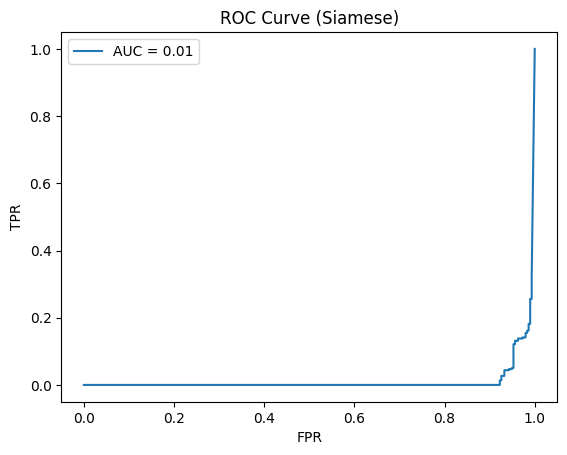

In [74]:
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve (Siamese)")
plt.legend()
plt.show()

Anomaly detection

In [75]:
def is_anomaly(sample, normal_set, threshold):
    distances = []

    for normal_sample in normal_set[:100]:  # compare with subset
        d = model.predict([sample[np.newaxis], normal_sample[np.newaxis]], verbose=0)
        distances.append(d[0][0])

    return np.mean(distances) > threshold

# test example
test_sample = X_val[0]
normal_reference = X_train[y_train == 0]

print("Is anomaly:", is_anomaly(test_sample, normal_reference, best_threshold))

Is anomaly: False
